# Wrangling Project
## Final Analysis 
#### Drew Peterson
***

## Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

## Read in the data frames

In [2]:
mlb_df = pd.read_csv("salary_analysis_merged_df.csv", index_col = 0)

display(mlb_df.head())

,Team,Team Name,Rank,Wins,Losses,Runs Allowed,Active,Total Cash
0,MIL,Milwaukee Brewers,1,97,65,3.9,84095680.0,140266827.0
1,PHI,Philadelphia Phillies,2,96,66,4.0,226300409.0,308208429.0
2,TOR,Toronto Blue Jays,3,94,68,4.5,179210208.0,290944111.0
3,NYY,New York Yankees,4,94,68,4.2,205097386.0,323561450.0
4,LAD,Los Angeles Dodgers,5,93,69,4.2,293126821.0,393082178.0


In [3]:
#Checks if dataframe was read correctly
display(mlb_df)
print(mlb_df.shape)
print(mlb_df.dtypes)
print(mlb_df.isna().sum())

,Team,Team Name,Rank,Wins,Losses,Runs Allowed,Active,Total Cash
0,MIL,Milwaukee Brewers,1,97,65,3.9,84095680.0,140266827.0
1,PHI,Philadelphia Phillies,2,96,66,4.0,226300409.0,308208429.0
2,TOR,Toronto Blue Jays,3,94,68,4.5,179210208.0,290944111.0
3,NYY,New York Yankees,4,94,68,4.2,205097386.0,323561450.0
4,LAD,Los Angeles Dodgers,5,93,69,4.2,293126821.0,393082178.0
5,CHC,Chicago Cubs,6,92,70,4.0,173037007.0,231356720.0
6,SEA,Seattle Mariners,7,90,72,4.3,131472218.0,193414894.0
7,SD,San Diego Padres,8,90,72,3.8,160473830.0,236031133.0
8,BOS,Boston Red Sox,9,89,73,4.2,122765355.0,229129601.0
9,CLE,Cleveland Guardians,10,88,74,4.0,50354620.0,118369450.0


(30, 8)
Team             object
Team Name        object
Rank              int64
Wins              int64
Losses            int64
Runs Allowed    float64
Active          float64
Total Cash      float64
dtype: object
Team            0
Team Name       0
Rank            0
Wins            0
Losses          0
Runs Allowed    0
Active          0
Total Cash      0
dtype: int64


## Creates variables for my analysis

In [4]:
mlb_df["Win Percentage"] = mlb_df["Wins"] / (mlb_df["Wins"] + mlb_df["Losses"])

mlb_df["Cost per Win"] = mlb_df["Active"] / mlb_df["Wins"]

mlb_df["Cash Difference"] = mlb_df["Total Cash"] - mlb_df["Active"]

mlb_df["Active Cash Ratio"] = mlb_df["Active"] / mlb_df["Total Cash"]

display(mlb_df.head())

,Team,Team Name,Rank,Wins,Losses,Runs Allowed,Active,Total Cash,Win Percentage,Cost per Win,Cash Difference,Active Cash Ratio
0,MIL,Milwaukee Brewers,1,97,65,3.9,84095680.0,140266827.0,0.598765,8.669658e+05,56171147.0,0.599541
1,PHI,Philadelphia Phillies,2,96,66,4.0,226300409.0,308208429.0,0.592593,2.357296e+06,81908020.0,0.734245
2,TOR,Toronto Blue Jays,3,94,68,4.5,179210208.0,290944111.0,0.580247,1.906492e+06,111733903.0,0.615961
3,NYY,New York Yankees,4,94,68,4.2,205097386.0,323561450.0,0.580247,2.181887e+06,118464064.0,0.633875
4,LAD,Los Angeles Dodgers,5,93,69,4.2,293126821.0,393082178.0,0.574074,3.151901e+06,99955357.0,0.745714


## Research Question 1
### Is there a correlation between payroll and team success?

In [5]:
corr_active_wins = mlb_df["Active"].corr(mlb_df["Wins"])
corr_total_wins = mlb_df["Total Cash"].corr(mlb_df["Wins"])

print("Correlation between Active Payroll and Wins:", round(corr_active_wins, 3))
print("Correlation between Total Cash and Wins:", round(corr_total_wins, 3))

Correlation between Active Payroll and Wins: 0.58
Correlation between Total Cash and Wins: 0.48


### Visualization 1: Scatterplot

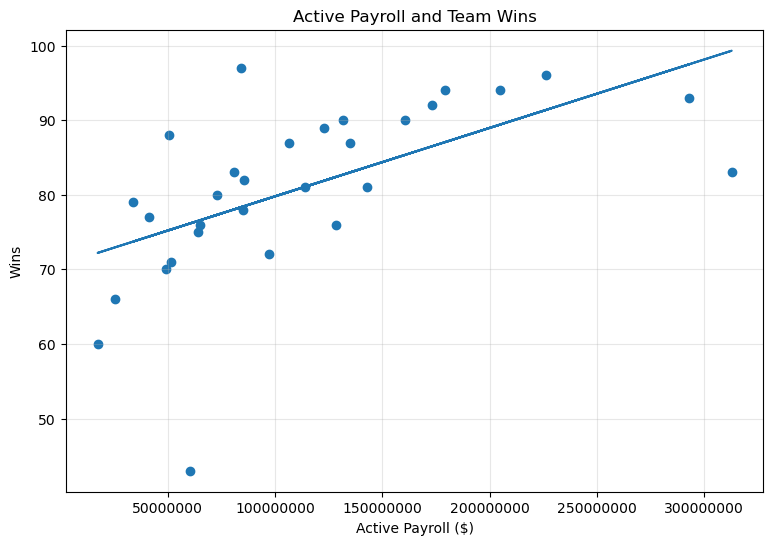

In [6]:
plt.figure(figsize=(9, 6))

plt.scatter(mlb_df["Active"], mlb_df["Wins"])

# Add regression line
x = mlb_df["Active"]
y = mlb_df["Wins"]
m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b)

plt.title("Active Payroll and Team Wins")
plt.xlabel("Active Payroll ($)")
plt.ylabel("Wins")

plt.ticklabel_format(style="plain", axis="x")
plt.grid(True, alpha=0.3)

plt.show()

## Research Question 2
### Which teams spent their money most effectively?

In [7]:
most_efficient = mlb_df.sort_values("Cost per Win").head(10)

least_efficient = mlb_df.sort_values("Cost per Win", ascending=False).head(10)

display(most_efficient[["Team", "Team Name","Rank", "Wins", "Active", "Cost per Win"]])
display(least_efficient[["Team", "Team Name","Rank",  "Wins", "Active", "Cost per Win"]])

,Team,Team Name,Rank,Wins,Active,Cost per Win
28,CHW,Chicago White Sox,29,60,17295751.0,288262.516667
27,WSH,Washington Nationals,28,66,25294554.0,383250.818182
18,MIA,Miami Marlins,19,79,33912751.0,429275.329114
20,TB,Tampa Bay Rays,21,77,41355049.0,537078.558442
9,CLE,Cleveland Guardians,10,88,50354620.0,572211.590909
26,MIN,Minnesota Twins,27,70,49208783.0,702982.614286
25,PIT,Pittsburgh Pirates,26,71,51549367.0,726047.422535
21,ATH,Athletics,22,76,64911684.0,854101.105263
23,BAL,Baltimore Orioles,24,75,64226457.0,856352.760000
0,MIL,Milwaukee Brewers,1,97,84095680.0,866965.773196


,Team,Team Name,Rank,Wins,Active,Cost per Win
12,NYM,New York Mets,13,83,312899806.0,3.769877e+06
4,LAD,Los Angeles Dodgers,5,93,293126821.0,3.151901e+06
1,PHI,Philadelphia Phillies,2,96,226300409.0,2.357296e+06
3,NYY,New York Yankees,4,94,205097386.0,2.181887e+06
2,TOR,Toronto Blue Jays,3,94,179210208.0,1.906492e+06
5,CHC,Chicago Cubs,6,92,173037007.0,1.880837e+06
7,SD,San Diego Padres,8,90,160473830.0,1.783043e+06
15,SF,San Francisco Giants,16,81,142688005.0,1.761580e+06
22,ATL,Atlanta Braves,23,76,128648209.0,1.692740e+06
10,HOU,Houston Astros,11,87,135180023.0,1.553793e+06


## Visualization 2: Bar chart

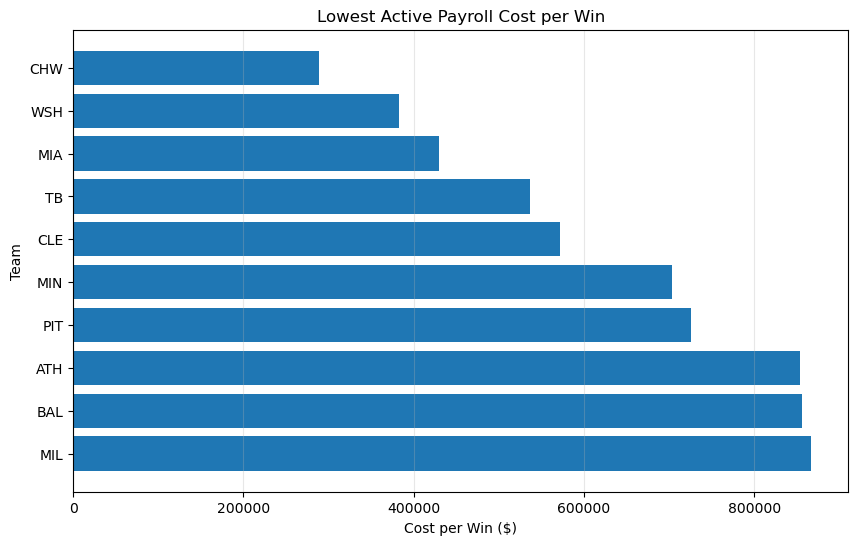

In [8]:
top_efficiency = mlb_df.sort_values("Cost per Win").head(10)

plt.figure(figsize=(10, 6))

plt.barh(top_efficiency["Team"], top_efficiency["Cost per Win"])

plt.title("Lowest Active Payroll Cost per Win")
plt.xlabel("Cost per Win ($)")
plt.ylabel("Team")

plt.ticklabel_format(style="plain", axis="x")
plt.gca().invert_yaxis()
plt.grid(True, axis="x", alpha=0.3)

plt.show()

## Wins compared to payroll tier

In [9]:
mlb_df["Payroll Tier"] = pd.qcut(
    mlb_df["Active"],
    q=3,
    labels=["Low Payroll", "Middle Payroll", "High Payroll"]
)

payroll_tier_summary = (
    mlb_df
    .groupby("Payroll Tier", observed=False)
    .agg(
        Average_Wins=("Wins", "mean"),
        Average_Active_Payroll=("Active", "mean"),
        Number_of_Teams=("Team", "count")
    )
    .reset_index()
)

display(payroll_tier_summary)

,Payroll Tier,Average_Wins,Average_Active_Payroll,Number_of_Teams
0,Low Payroll,70.5,45841248.2,10
1,Middle Payroll,82.5,97819534.1,10
2,High Payroll,90.0,195948571.3,10


## Research Question 3
### Active cash vs. total cash: which teams were most frugal, and did it help?

In [10]:
most_frugal = mlb_df.sort_values("Active Cash Ratio").head(10)

display(most_frugal[[
    "Team",
    "Team Name",
    "Wins",
    "Active",
    "Total Cash",
    "Cash Difference",
    "Active Cash Ratio"
]])

,Team,Team Name,Wins,Active,Total Cash,Cash Difference,Active Cash Ratio
27,WSH,Washington Nationals,66,25294554.0,149257229.0,123962675.0,0.169470
28,CHW,Chicago White Sox,60,17295751.0,101146763.0,83851012.0,0.170997
23,BAL,Baltimore Orioles,75,64226457.0,196376385.0,132149928.0,0.327058
26,MIN,Minnesota Twins,70,49208783.0,150415875.0,101207092.0,0.327152
17,ARI,Arizona Diamondbacks,80,73085886.0,204349736.0,131263850.0,0.357651
18,MIA,Miami Marlins,79,33912751.0,90652027.0,56739276.0,0.374098
20,TB,Tampa Bay Rays,77,41355049.0,102798243.0,61443194.0,0.402293
29,COL,Colorado Rockies,43,60303466.0,149531167.0,89227701.0,0.403284
24,LAA,Los Angeles Angels,72,97348952.0,230062125.0,132713173.0,0.423142
9,CLE,Cleveland Guardians,88,50354620.0,118369450.0,68014830.0,0.425402


In [11]:
corr_ratio_wins = mlb_df["Active Cash Ratio"].corr(mlb_df["Wins"])

print("Correlation between Active Cash Ratio and Wins:", round(corr_ratio_wins, 3))

Correlation between Active Cash Ratio and Wins: 0.687


## Visualization 3: Boxplot by active cash ratio group

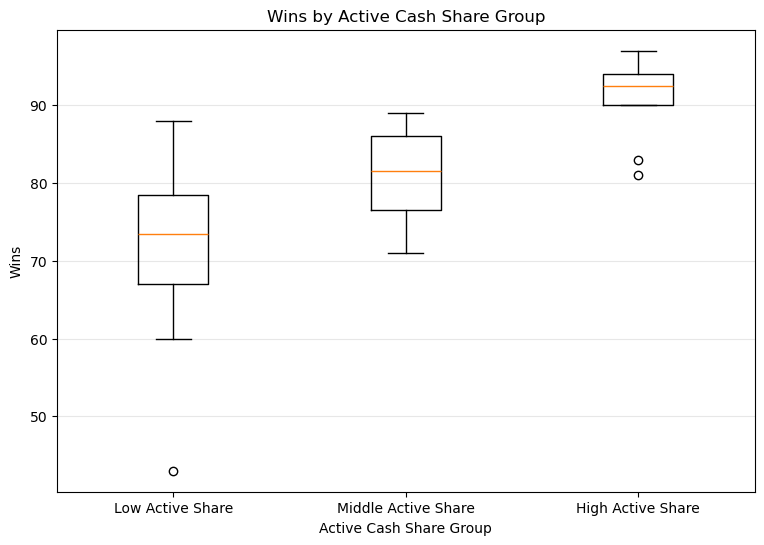

In [12]:
mlb_df["Active Cash Group"] = pd.qcut(
    mlb_df["Active Cash Ratio"],
    q=3,
    labels=["Low Active Share", "Middle Active Share", "High Active Share"]
)

plt.figure(figsize=(9, 6))

groups = [
    mlb_df[mlb_df["Active Cash Group"] == "Low Active Share"]["Wins"],
    mlb_df[mlb_df["Active Cash Group"] == "Middle Active Share"]["Wins"],
    mlb_df[mlb_df["Active Cash Group"] == "High Active Share"]["Wins"]
]

plt.boxplot(
    groups, 
    tick_labels=["Low Active Share", "Middle Active Share", "High Active Share"]
)

plt.title("Wins by Active Cash Share Group")
plt.xlabel("Active Cash Share Group")
plt.ylabel("Wins")
plt.grid(True, axis="y", alpha=0.3)

plt.show()

In [13]:
cash_group_summary = (
    mlb_df
    .groupby("Active Cash Group", observed=False)
    .agg(
        Average_Wins=("Wins", "mean"),
        Average_Active_Cash_Ratio=("Active Cash Ratio", "mean"),
        Number_of_Teams=("Team", "count")
    )
    .reset_index()
)

display(cash_group_summary)

,Active Cash Group,Average_Wins,Average_Active_Cash_Ratio,Number_of_Teams
0,Low Active Share,71.0,0.338055,10
1,Middle Active Share,81.0,0.543299,10
2,High Active Share,91.0,0.692828,10


## Spending Most and Least

In [14]:
most_spending = mlb_df.sort_values("Active", ascending=False).head(10)
least_spending = mlb_df.sort_values("Active").head(10)

display(most_spending[["Team", "Team Name", "Wins", "Active", "Total Cash"]])
display(least_spending[["Team", "Team Name", "Wins", "Active", "Total Cash"]])

,Team,Team Name,Wins,Active,Total Cash
12,NYM,New York Mets,83,312899806.0,400965292.0
4,LAD,Los Angeles Dodgers,93,293126821.0,393082178.0
1,PHI,Philadelphia Phillies,96,226300409.0,308208429.0
3,NYY,New York Yankees,94,205097386.0,323561450.0
2,TOR,Toronto Blue Jays,94,179210208.0,290944111.0
5,CHC,Chicago Cubs,92,173037007.0,231356720.0
7,SD,San Diego Padres,90,160473830.0,236031133.0
15,SF,San Francisco Giants,81,142688005.0,200678481.0
10,HOU,Houston Astros,87,135180023.0,253425770.0
6,SEA,Seattle Mariners,90,131472218.0,193414894.0


,Team,Team Name,Wins,Active,Total Cash
28,CHW,Chicago White Sox,60,17295751.0,101146763.0
27,WSH,Washington Nationals,66,25294554.0,149257229.0
18,MIA,Miami Marlins,79,33912751.0,90652027.0
20,TB,Tampa Bay Rays,77,41355049.0,102798243.0
26,MIN,Minnesota Twins,70,49208783.0,150415875.0
9,CLE,Cleveland Guardians,88,50354620.0,118369450.0
25,PIT,Pittsburgh Pirates,71,51549367.0,104739138.0
29,COL,Colorado Rockies,43,60303466.0,149531167.0
23,BAL,Baltimore Orioles,75,64226457.0,196376385.0
21,ATH,Athletics,76,64911684.0,113857137.0
